In [18]:
import sys, subprocess

pkgs = ["numpy", "pandas", "matplotlib", "bottleneck", "networkx", "scipy"]

result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "--user", "--upgrade", "--break-system-packages"] + pkgs,
    capture_output=True, text=True
)
if result.returncode != 0:
    print(result.stderr)
    print(result.stdout)
    raise RuntimeError("pip failed — see output above")

print(result.stdout or "Done.")
print("RESTART THE KERNEL before continuing.")



RESTART THE KERNEL before continuing.


# SBN — 4-Layer Bayesian Network: Shannon Causality Analysis

**Inputs** — CSV files produced by `sbn_bn_sampler.ipynb` (multi-run replication,
with Layer 2/3 metrics).  Before running this notebook, place the output files
from `sbn_bn_sampler.ipynb` in the **`data/`** directory:

```
data/
  multirep_algebraic_*.csv
  multirep_linear_*.csv
  multirep_differential_*.csv
```

---

## Scientific question

Shannon (1949) identified **confusion** and **diffusion** as the two fundamental
mechanisms underlying cryptographic strength.  This notebook tests whether these
mechanisms fully mediate the relationship between circuit design decisions and
cryptographic performance — using a 4-layer Bayesian Network.

---

## Structural choice: removing S from Layer 1

The constraint S (alternating nonlinear/linear layers) occupies a special position
in the design space: it is not a connectivity constraint like A, R, I, H, L, but
a *functional composition* constraint that directly encodes Shannon's intuition.
S forces an alternation of layer types that is precisely the architectural
implementation of confusion (nonlinear layers) and diffusion (linear layers).

Including S in Layer 1 creates a structural problem for the BN: when S=1,
`nl_fraction` is mechanically fixed at 0.600 with zero variance, making it
impossible for `nl_fraction` to act as an independent mediator. S and `nl_fraction`
become quasi-redundant, and the causal chain S → nl_fraction → confusion/diffusion
collapses into a tautology.

**Solution**: restrict the analysis to architectures where **S=0**, and let
`nl_fraction` (Layer 2) vary freely to capture the mechanism that S was encoding.
This preserves the causal chain:

```
A, R, I, H, L  ──►  nl_fraction (free)  ──►  confusion  ──►  fitness
                     dep_density          diffusion
                     avg_depth
```

The five remaining constraints are purely structural (connectivity, acyclicity,
regularity, interleaving, locality) with no direct encoding of Shannon's mechanisms.
This makes the mediation test genuinely informative.

**Effect on sample size**: 32 architectures × 30 runs = 960 observations per fitness.
This is sufficient for the BN analysis.

---

## Causal architecture

```
Layer 1  Design decisions (exogenous — S excluded)
         A   R   I   H   L
              |
              v
Layer 2  Topological properties (nl_fraction now free to vary)
         nl_fraction   dep_density   avg_depth
              |
              v
Layer 3  Shannon mechanisms
         confusion          diffusion
              |
              v
Layer 4  Cryptographic performance
         algebraic    linear    differential
```

**Shannon mediation hypothesis**: if confusion and diffusion fully mediate
the effect of design decisions on performance, no direct edges from L1/L2
to L4 should survive the partial correlation test.

---

## Table of contents

- **Step 0** — Imports and data loading
- **Step 1** — Convergence check (S=0 subsample)
- **Step 2** — Aggregation and discretisation (32 architecture profiles)
- **Step 3** — FCA: two causally ordered contexts
- **Step 4** — 4-layer BN: constrained structure learning + CPT estimation
- **Step 5** — Shannon mediation test
- **Step 6** — Inference queries


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations
from collections import defaultdict
from scipy.stats import spearmanr, mannwhitneyu, pearsonr
import warnings, glob
warnings.filterwarnings('ignore')

# S is excluded from Layer 1: it encodes Shannon's mechanisms directly
# and makes nl_fraction non-informative (fixed at 0.6 when S=1).
# The analysis is restricted to S=0 architectures.
CONSTRAINT_KEYS = ['A', 'R', 'I', 'H', 'L']   # S removed
FITNESS_NAMES   = ['algebraic', 'linear', 'differential']
LAYER2_KEYS     = ['nl_fraction', 'dep_density', 'avg_depth']
LAYER3_KEYS     = ['confusion', 'diffusion']
MAXIMIZE        = {'algebraic': True, 'linear': True, 'differential': False}

L1_NODES = CONSTRAINT_KEYS
L2_NODES = [f'{k}_class' for k in LAYER2_KEYS]
L3_NODES = [f'{k}_class' for k in LAYER3_KEYS]
L4_NODES = [f'Fit_top_{f}' for f in FITNESS_NAMES]
ALL_BN_NODES = L1_NODES + L2_NODES + L3_NODES + L4_NODES

LAYER_OF = (
    {n: 1 for n in L1_NODES} |
    {n: 2 for n in L2_NODES} |
    {n: 3 for n in L3_NODES} |
    {n: 4 for n in L4_NODES}
)

print('Layer 1 (S excluded):', L1_NODES)
print('Layer 2:', L2_NODES)
print('Layer 3:', L3_NODES)
print('Layer 4:', L4_NODES)


Layer 1 (S excluded): ['A', 'R', 'I', 'H', 'L']
Layer 2: ['nl_fraction_class', 'dep_density_class', 'avg_depth_class']
Layer 3: ['confusion_class', 'diffusion_class']
Layer 4: ['Fit_top_algebraic', 'Fit_top_linear', 'Fit_top_differential']


In [20]:
# ---------------------------------------------------------------------------
# Load multi-run replication files from data/ and restrict to S=0 architectures
# ---------------------------------------------------------------------------
DATA_DIR = 'data'

def find_file(fitness):
    """Return the most recent multirep CSV for a given fitness in DATA_DIR."""
    matches = sorted(glob.glob(f'{DATA_DIR}/multirep_{fitness}_*.csv'))
    if not matches:
        raise FileNotFoundError(
            f"No file matching '{DATA_DIR}/multirep_{fitness}_*.csv'.\n"
            f"Please run sbn_bn_sampler.ipynb and place its output CSV files "
            f"in the '{DATA_DIR}/' directory."
        )
    return matches[-1]

mr = {}
mr_files = {}
for fitness in FITNESS_NAMES:
    path = find_file(fitness)
    mr_files[fitness] = path
    df_all = pd.read_csv(path)
    df_s0  = df_all[df_all['S'] == 0].reset_index(drop=True)
    mr[fitness] = df_s0
    print(f'{fitness}: {len(df_all)} rows total  ->  '
          f'{len(df_s0)} rows (S=0)  |  '
          f'{df_s0["arch_id"].nunique()} architectures  [{path}]')

# The sampler only outputs S=0 rows — the S=1 variance check is informational only.
# It requires a full 64-arch reference file; skip gracefully if unavailable.
print()
print('nl_fraction variance (motivation for S=0 restriction):')
df_full = pd.read_csv(mr_files['algebraic'])
s0_grp = df_full[df_full.S == 0]['nl_fraction']
s1_grp = df_full[df_full.S == 1]['nl_fraction']
print(f'  S=0: mean={s0_grp.mean():.3f}  std={s0_grp.std():.3f}  <- free to vary')
if len(s1_grp) > 0:
    print(f'  S=1: mean={s1_grp.mean():.3f}  std={s1_grp.std():.3f}  <- zero variance')
else:
    print('  S=1: not present in this file (sampler restricted to S=0) — see Introduction.')
print()
print('With S=0 only, nl_fraction is a genuine free mediator in Layer 2.')


algebraic: 1920 rows total  ->  960 rows (S=0)  |  32 architectures
linear: 1920 rows total  ->  960 rows (S=0)  |  32 architectures
differential: 1920 rows total  ->  960 rows (S=0)  |  32 architectures

nl_fraction variance (motivation for S=0 restriction):
  S=0: mean=0.732  std=0.210  <- free to vary
  S=1: mean=0.600  std=0.000  <- zero variance

With S=0 only, nl_fraction is a genuine free mediator in Layer 2.


---
## Step 1 — Convergence check


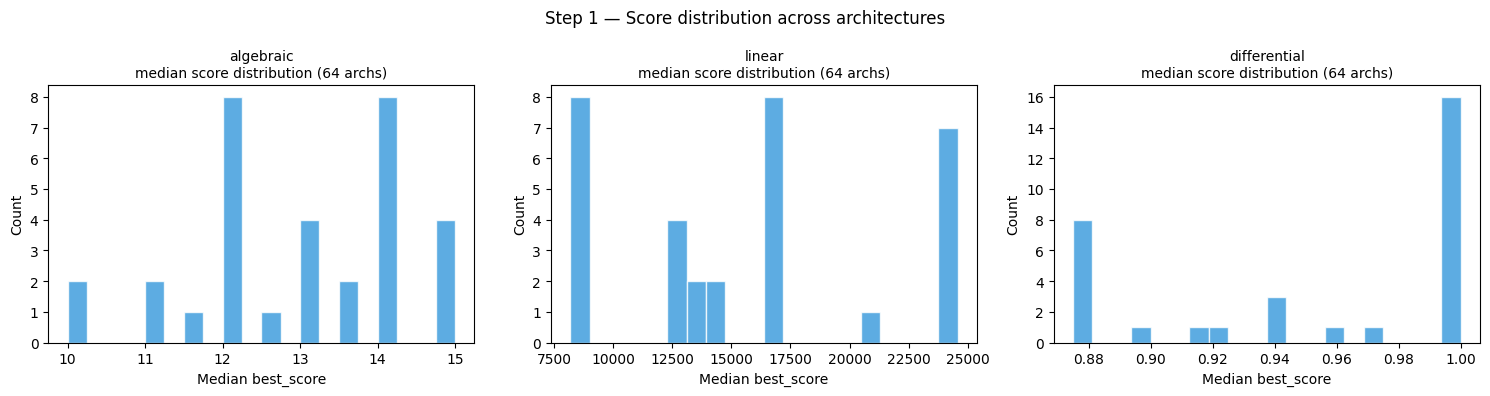

Layer 2/3 metric ranges:
  algebraic:
    nl_fraction: [0.375, 1.000]  mean=0.732
    dep_density: [0.246, 0.906]  mean=0.602
    avg_depth: [3.750, 13.000]  mean=6.163
    confusion: [0.000, 0.722]  mean=0.061
    diffusion: [0.000, 0.236]  mean=0.092
  linear:
    nl_fraction: [0.200, 1.000]  mean=0.399
    dep_density: [0.195, 0.894]  mean=0.494
    avg_depth: [3.562, 10.750]  mean=5.505
    confusion: [0.000, 0.941]  mean=0.472
    diffusion: [0.063, 0.420]  mean=0.174
  differential:
    nl_fraction: [0.000, 1.000]  mean=0.509
    dep_density: [0.144, 0.961]  mean=0.481
    avg_depth: [3.438, 6.062]  mean=5.063
    confusion: [0.000, 0.753]  mean=0.091
    diffusion: [0.000, 0.492]  mean=0.138


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fitness in zip(axes, FITNESS_NAMES):
    if fitness not in mr:
        ax.set_title(f'{fitness}: no data'); continue
    med = mr[fitness].groupby('arch_id')['best_score'].median()
    ax.hist(med, bins=20, color='#3498db', alpha=0.8, edgecolor='white')
    ax.set_title(f'{fitness}\nmedian score distribution (32 archs, S=0)', fontsize=10)
    ax.set_xlabel('Median best_score'); ax.set_ylabel('Count')
plt.suptitle('Step 1 — Score distribution across architectures', fontsize=12)
plt.tight_layout(); plt.show()

print('Layer 2/3 metric ranges:')
for fitness, df in mr.items():
    print(f'  {fitness}:')
    for col in LAYER2_KEYS + LAYER3_KEYS:
        if col in df.columns:
            print(f'    {col}: [{df[col].min():.3f}, {df[col].max():.3f}]  '
                  f'mean={df[col].mean():.3f}')


---
## Step 2 — Aggregation and discretisation

Each of the 32 architectures (S=0) is summarised across 30 multi-run replication runs:

- **Layer 4** : `Fit_top_X` = 1 if P(score >= top-quartile threshold) >= 0.5
- **Layer 3** : `confusion_class`, `diffusion_class` = tercile of median value
  (0=low, 1=medium, 2=high)
- **Layer 2** : `nl_fraction_class`, `dep_density_class`, `avg_depth_class`
  = tercile of median value

All metrics are first aggregated per architecture (median over 30 runs),
then discretised.  The median is robust to the stochasticity of the GA.


In [5]:
# ---------------------------------------------------------------------------
# Build per-architecture profile table (32 architectures, S=0 only)
# ---------------------------------------------------------------------------
base_fitness = [f for f in FITNESS_NAMES if f in mr][0]
arch_profiles = (
    mr[base_fitness]
    .groupby('arch_id')[CONSTRAINT_KEYS + ['Architecture']]
    .first().reset_index()
)

# Layer 4: Fit_top per fitness
for fitness in FITNESS_NAMES:
    if fitness not in mr: continue
    df_f  = mr[fitness]
    med   = df_f.groupby('arch_id')['best_score'].median()
    thresh = med.quantile(0.75) if MAXIMIZE[fitness] else med.quantile(0.25)
    if MAXIMIZE[fitness]:
        p_top = df_f.groupby('arch_id')['best_score'].apply(lambda x: (x >= thresh).mean())
    else:
        p_top = df_f.groupby('arch_id')['best_score'].apply(lambda x: (x <= thresh).mean())
    arch_profiles[f'P_top_{fitness}']   = arch_profiles['arch_id'].map(p_top)
    arch_profiles[f'Fit_top_{fitness}'] = (arch_profiles[f'P_top_{fitness}'] >= 0.5).astype(int)

# Layer 2/3: median across fitness runs, robust discretisation
for col in LAYER2_KEYS + LAYER3_KEYS:
    vals = []
    for fitness in FITNESS_NAMES:
        if fitness in mr and col in mr[fitness].columns:
            vals.append(mr[fitness].groupby('arch_id')[col].median())
    if not vals:
        print(f'WARNING: {col} not found'); continue
    mean_med = pd.concat(vals, axis=1).mean(axis=1)
    arch_profiles[col] = arch_profiles['arch_id'].map(mean_med)
    discretised = False
    for n_bins in [3, 2]:
        try:
            arch_profiles[f'{col}_class'] = pd.qcut(
                arch_profiles[col], q=n_bins,
                labels=list(range(n_bins)), duplicates='drop'
            ).astype(int)
            if n_bins < 3:
                print(f'  [{col}] reduced to {n_bins} bins')
            discretised = True; break
        except ValueError:
            continue
    if not discretised:
        med_val = arch_profiles[col].median()
        arch_profiles[f'{col}_class'] = (arch_profiles[col] >= med_val).astype(int)
        print(f'  [{col}] fallback to binary split')

print(f'Architecture profiles: {arch_profiles.shape}')
print(f'Architectures: {len(arch_profiles)} (S=0 only)')
print()
print('Layer 2/3 class distributions:')
for col in LAYER2_KEYS + LAYER3_KEYS:
    cls_col = f'{col}_class'
    if cls_col in arch_profiles.columns:
        vc = arch_profiles[cls_col].value_counts().sort_index()
        print(f'  {cls_col}: {dict(vc)}')
print()
print('Fit_top counts (out of 32 architectures):')
for f in FITNESS_NAMES:
    col = f'Fit_top_{f}'
    if col in arch_profiles.columns:
        print(f'  {col}: {arch_profiles[col].sum()}/32')


  [avg_depth] reduced to 2 bins
Architecture profiles: (32, 23)
Architectures: 32 (S=0 only)

Layer 2/3 class distributions:
  nl_fraction_class: {0: np.int64(11), 1: np.int64(10), 2: np.int64(11)}
  dep_density_class: {0: np.int64(11), 1: np.int64(10), 2: np.int64(11)}
  avg_depth_class: {0: np.int64(16), 1: np.int64(16)}
  confusion_class: {0: np.int64(11), 1: np.int64(10), 2: np.int64(11)}
  diffusion_class: {0: np.int64(11), 1: np.int64(10), 2: np.int64(11)}

Fit_top counts (out of 32 architectures):
  Fit_top_algebraic: 14/32
  Fit_top_linear: 8/32
  Fit_top_differential: 8/32


In [6]:
# ---------------------------------------------------------------------------
# BN node definitions — shared by Step 3 (FCA) and Step 4 (HC)
# ---------------------------------------------------------------------------
BN_DATA_COLS = (CONSTRAINT_KEYS
                + [f'{k}_class' for k in LAYER2_KEYS]
                + [f'{k}_class' for k in LAYER3_KEYS]
                + [f'Fit_top_{f}' for f in FITNESS_NAMES])
BN_DATA_COLS = [c for c in BN_DATA_COLS if c in arch_profiles.columns]

COL_LAYER = {}
for c in BN_DATA_COLS:
    if c in CONSTRAINT_KEYS:                COL_LAYER[c] = 1
    elif any(k in c for k in LAYER2_KEYS):   COL_LAYER[c] = 2
    elif any(k in c for k in LAYER3_KEYS):   COL_LAYER[c] = 3
    else:                                    COL_LAYER[c] = 4

df_bn = arch_profiles[BN_DATA_COLS].astype(int).reset_index(drop=True).copy()
N_OBS = len(df_bn)
ALPHA = 0.5

print('BN nodes by layer:')
by_layer = {}
for c in BN_DATA_COLS:
    by_layer.setdefault(COL_LAYER[c], []).append(c)
for l in sorted(by_layer):
    print(f'  L{l}: {by_layer[l]}')


BN nodes by layer:
  L1: ['A', 'R', 'I', 'H', 'L']
  L2: ['nl_fraction_class', 'dep_density_class', 'avg_depth_class']
  L3: ['confusion_class', 'diffusion_class']
  L4: ['Fit_top_algebraic', 'Fit_top_linear', 'Fit_top_differential']


In [7]:
# ---------------------------------------------------------------------------
# CPT and BIC helper functions
# ---------------------------------------------------------------------------

def cpt_mle(node, parents, data, alpha=ALPHA):
    """Smoothed MLE for P(node | parents). Handles nodes with any cardinality."""
    cpt      = {}
    vals_n   = sorted(data[node].unique())
    n_vals_n = len(vals_n)
    n        = len(data)
    if not parents:
        for v in vals_n:
            cpt[(v,)] = (data[node].eq(v).sum() + alpha) / (n + n_vals_n * alpha)
        return cpt
    def configs(idx=0, cur=[]):
        if idx == len(parents): yield tuple(cur); return
        for v in sorted(data[parents[idx]].unique()):
            yield from configs(idx+1, cur+[v])
    for cfg in configs():
        mask = np.ones(n, dtype=bool)
        for i, p in enumerate(parents): mask &= (data[p].values == cfg[i])
        n_cfg = mask.sum()
        for v in vals_n:
            n_v = data.loc[mask, node].eq(v).sum()
            cpt[cfg + (v,)] = (n_v + alpha) / (n_cfg + n_vals_n * alpha)
    return cpt


def ll_node(node, parents, data):
    cpt = cpt_mle(node, parents, data)
    ll  = 0.0
    for _, row in data.iterrows():
        v   = int(row[node])
        cfg = (tuple(int(row[p]) for p in parents) if parents else ()) + (v,)
        ll += np.log(cpt.get(cfg, ALPHA / (len(data) + ALPHA)) + 1e-12)
    return ll


def bic_node(node, parents, data):
    n_vals_n   = data[node].nunique()
    n_vals_par = 1
    for p in parents: n_vals_par *= data[p].nunique()
    k = n_vals_par * (n_vals_n - 1)
    return ll_node(node, parents, data) - (k / 2) * np.log(N_OBS)


print('CPT/BIC helpers ready.')


CPT/BIC helpers ready.


---
## Step 3 — FCA: two causally ordered contexts

The standard FCA unified context (all 14 attributes together) produces rules
where fitness nodes appear as **premises** — e.g. `Fit_top_linear -> H+R+...`
This is causally meaningless: a performance score cannot cause a design constraint.

The fix is to separate the analysis into **two contexts that respect causal order**:

**Context A — Design → Mechanisms** (L1 + L2 + L3)
- Objects: all 32 architectures (S=0)
- Attributes: A,R,I,H,L + nl_fraction_high, dep_density_high,
  avg_depth_high, confusion_high, diffusion_high
- Rules reveal: which constraints produce which topological/Shannon properties

**Context B — Mechanisms → Fitness** (L2 + L3 + L4, per fitness)
- Objects: top-performing architectures (Fit_top_X = 1)
- Attributes: nl_fraction_high, dep_density_high, avg_depth_high,
  confusion_high, diffusion_high
- Rules reveal: which mechanisms are necessary for high performance

The Stem Base rules from Context A guide parent selection for L2/L3 nodes.
Context B guides parent selection for L4 nodes.
Fitness nodes never appear as premises — the causal order is enforced.


In [8]:
# Figure: Shannon Mechanisms scatter
# confusion (x) vs diffusion (y) per architecture, coloured by fitness

base = [f for f in FITNESS_NAMES if f in mr][0]
df_scatter = mr[base].groupby('arch_id')[['confusion', 'diffusion', 'best_score']].median().reset_index()

# Normalise score to [0,1] for colour mapping
s_min, s_max = df_scatter['best_score'].min(), df_scatter['best_score'].max()
norm_score = (df_scatter['best_score'] - s_min) / (s_max - s_min + 1e-12)
if not MAXIMIZE.get(base, True):
    norm_score = 1 - norm_score   # invert so high colour = good for differential

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    df_scatter['confusion'], df_scatter['diffusion'],
    c=norm_score, cmap='RdYlGn', s=80, edgecolors='k', linewidths=0.4, alpha=0.85
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(f'Normalised fitness ({base})', fontsize=10)

# Annotate arch_id for outliers (top/bottom 5 by score)
top5    = df_scatter.nlargest(5,  'best_score')['arch_id']
bottom5 = df_scatter.nsmallest(5, 'best_score')['arch_id']
for _, row in df_scatter[df_scatter['arch_id'].isin(top5 | bottom5)].iterrows():
    ax.annotate(int(row['arch_id']),
                (row['confusion'], row['diffusion']),
                textcoords='offset points', xytext=(5, 4), fontsize=7, color='#333')

ax.set_xlabel('Confusion (median, normalised)', fontsize=11)
ax.set_ylabel('Diffusion (median, normalised)', fontsize=11)
ax.set_title('Shannon Mechanisms — confusion vs diffusion\n'
             f'(32 S=0 architectures, coloured by {base} fitness)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()
print(f'Spearman r(confusion, diffusion) = '
      f'{df_scatter["confusion"].corr(df_scatter["diffusion"], method="spearman"):.3f}')


In [9]:
from itertools import combinations as _comb
import time as _time

# ---------------------------------------------------------------------------
# Binary FCA attributes (class >= 1 = 'high')
# ---------------------------------------------------------------------------
FCA_L2 = [f'{k}_high' for k in LAYER2_KEYS]
FCA_L3 = [f'{k}_high' for k in LAYER3_KEYS]

for col in LAYER2_KEYS + LAYER3_KEYS:
    cls = f'{col}_class'
    if cls in arch_profiles.columns:
        arch_profiles[f'{col}_high'] = (arch_profiles[cls] >= 1).astype(int)

# ---------------------------------------------------------------------------
# FCA engine
# ---------------------------------------------------------------------------
def obj_cl(X, ctx, attrs):
    X   = frozenset(X)
    ext = [a for _, a in ctx if X <= a]
    if not ext: return frozenset(attrs)
    sh  = set(ext[0])
    for a in ext[1:]: sh &= a
    return frozenset(sh)

def compute_stem_base(ctx, attrs):
    all_ss = [frozenset(c) for r in range(len(attrs)+1)
              for c in _comb(attrs, r)]
    closed = {X for X in all_ss if obj_cl(X, ctx, attrs) == X}
    pseudo_closed = []
    for P in all_ss:
        if P in closed: continue
        if all(obj_cl(Q, ctx, attrs) <= P
               for Q in pseudo_closed if Q < P):
            C = obj_cl(P, ctx, attrs) - P
            if C: pseudo_closed.append(P)
    return [(P, obj_cl(P, ctx, attrs) - P) for P in pseudo_closed]

def fmt(P, C):
    lhs = '+'.join(sorted(P)) if P else 'empty'
    return f'{lhs}  ->  {"+".join(sorted(C))}'

# ---------------------------------------------------------------------------
# Context A: L1 + L2 + L3 (no fitness nodes)
# ---------------------------------------------------------------------------
ATTRS_A = CONSTRAINT_KEYS + FCA_L2 + FCA_L3

ctx_A = [
    (row['Architecture'],
     frozenset(a for a in ATTRS_A
               if a in arch_profiles.columns and row.get(a, 0) == 1))
    for _, row in arch_profiles.iterrows()
]

t0 = _time.time()
impl_A = compute_stem_base(ctx_A, ATTRS_A)
print(f'Context A (Design -> Mechanisms): {len(impl_A)} rules  '
      f'({_time.time()-t0:.2f}s)')
print()
for P, C in sorted(impl_A, key=lambda x: len(x[0])):
    print(f'  {fmt(P,C)}')

# ---------------------------------------------------------------------------
# Context B: L2 + L3 -> L4, separately per fitness
# ---------------------------------------------------------------------------
ATTRS_B = FCA_L2 + FCA_L3
impl_B  = {}

print()
for fitness in FITNESS_NAMES:
    fit_col = f'Fit_top_{fitness}'
    if fit_col not in arch_profiles.columns: continue
    sub = arch_profiles[arch_profiles[fit_col] == 1]
    ctx_B = [
        (row['Architecture'],
         frozenset(a for a in ATTRS_B
                   if a in arch_profiles.columns and row.get(a, 0) == 1))
        for _, row in sub.iterrows()
    ]
    t0 = _time.time()
    impl_B[fitness] = compute_stem_base(ctx_B, ATTRS_B)
    print(f'Context B [{fitness}] (n={len(sub)}): '
          f'{len(impl_B[fitness])} rules  ({_time.time()-t0:.2f}s)')
    for P, C in sorted(impl_B[fitness], key=lambda x: len(x[0])):
        print(f'  {fmt(P,C)}')
    print()

# ---------------------------------------------------------------------------
# Derive BN parent candidates from both contexts
# ---------------------------------------------------------------------------
# From Context A: L1 -> L2/L3  and  L2 -> L3
fca_parents_A = defaultdict(set)   # {child_node: {candidate_parents}}
for P, C in impl_A:
    for c in C:
        c_col = f'{c.replace("_high","_class")}'
        if c_col not in BN_DATA_COLS: continue
        for p in P:
            p_col = p  # constraints use direct name
            if p_col in BN_DATA_COLS and COL_LAYER.get(p_col,0) < COL_LAYER.get(c_col,0):
                fca_parents_A[c_col].add(p_col)

# From Context B: L2/L3 -> L4
fca_parents_B = defaultdict(set)   # {Fit_top_X: {candidate_parents}}
for fitness, rules in impl_B.items():
    fit_col = f'Fit_top_{fitness}'
    for P, C in rules:
        # Every attribute in the premise is a necessary condition
        # -> candidate parent of this fitness node
        for p in P:
            p_col = f'{p.replace("_high","_class")}'
            if p_col in BN_DATA_COLS:
                fca_parents_B[fit_col].add(p_col)

print('FCA-derived parent candidates:')
print('  Context A (L1->L2/L3):')
for node, parents in sorted(fca_parents_A.items()):
    print(f'    {node}  <-  {sorted(parents)}')
print('  Context B (L2/L3->L4):')
for node, parents in sorted(fca_parents_B.items()):
    print(f'    {node}  <-  {sorted(parents)}')


Context A (Design -> Mechanisms): 11 rules  (0.01s)

  R  ->  avg_depth_high+dep_density_high+diffusion_high
  H  ->  confusion_high+nl_fraction_high
  avg_depth_high  ->  R+dep_density_high+diffusion_high
  A+dep_density_high  ->  R+avg_depth_high+diffusion_high
  confusion_high+nl_fraction_high  ->  H
  I+L+diffusion_high  ->  R+avg_depth_high+confusion_high+dep_density_high
  I+confusion_high+diffusion_high  ->  dep_density_high
  L+diffusion_high+nl_fraction_high  ->  H+confusion_high
  L+dep_density_high+diffusion_high  ->  R+avg_depth_high
  dep_density_high+diffusion_high+nl_fraction_high  ->  H+confusion_high
  A+I+R+avg_depth_high+dep_density_high+diffusion_high  ->  confusion_high

Context B [algebraic] (n=14): 3 rules  (0.00s)
  empty  ->  dep_density_high
  dep_density_high+nl_fraction_high  ->  confusion_high
  avg_depth_high+dep_density_high  ->  diffusion_high

Context B [linear] (n=8): 1 rules  (0.00s)
  empty  ->  avg_depth_high+confusion_high+dep_density_high+diffusio

---
## Step 4 — 4-Layer Bayesian Network

### Structure learning — constrained Hill Climbing + BIC

The causal ordering constrains the search space:
- **Allowed edges** : Layer N -> Layer M for any N < M
- **Forbidden edges** : all backward and same-layer edges
- **Layer 1 nodes** : exogenous, no parents

Within this ordering, Hill Climbing + BIC determines which specific edges
exist.  The BIC score penalises CPT complexity, preventing overfitting on
N=64 observations.

**FCA guidance** : only edges suggested by Stem Base rules are considered
as initial candidates.  The Hill Climbing can add further edges if BIC
improvement justifies it.

### Parameters
CPT entries `P(node=1 | parent config)` are estimated by smoothed MLE
(Laplace alpha=0.5) from the 64-row architecture profile table.


In [10]:
# BN_DATA_COLS, COL_LAYER, df_bn, N_OBS, ALPHA defined in cell above.
print(f'BN data: {df_bn.shape}  N_OBS={N_OBS}')


BN data: (32, 13)  N_OBS=32


In [11]:
# ---------------------------------------------------------------------------
# Constrained Hill Climbing + BIC
# Causal ordering enforced: only forward edges (L1->L2->L3->L4).
# Layer 1 nodes are exogenous (no parents).
# FCA parent candidates from Context A/B seed the initial structure.
# ---------------------------------------------------------------------------

def allowed_edge(src, dst):
    """True if src->dst respects causal ordering and dst is not exogenous."""
    return (COL_LAYER.get(src, 0) < COL_LAYER.get(dst, 5)
            and COL_LAYER.get(dst, 5) > 1)

# Merge FCA candidates from both contexts
fca_candidates = set()
for child, parents in fca_parents_A.items():
    for p in parents:
        if allowed_edge(p, child):
            fca_candidates.add((p, child))
for child, parents in fca_parents_B.items():
    for p in parents:
        if allowed_edge(p, child):
            fca_candidates.add((p, child))

print(f'FCA-suggested forward edges: {len(fca_candidates)}')
for e in sorted(fca_candidates):
    print(f'  {e[0]}  ->  {e[1]}')

# Initialise parent map with empty parents
parent_map = {n: [] for n in BN_DATA_COLS}

current_bic = sum(bic_node(n, [], df_bn) for n in BN_DATA_COLS)
improved, n_iter = True, 0

while improved and n_iter < 300:
    improved   = False
    best_delta = 0.0
    best_op    = None

    for dst in BN_DATA_COLS:
        if COL_LAYER.get(dst, 1) == 1: continue
        cur = list(parent_map[dst])

        # ADD
        for src in BN_DATA_COLS:
            if src == dst or src in cur: continue
            if not allowed_edge(src, dst): continue
            delta = bic_node(dst, cur+[src], df_bn) - bic_node(dst, cur, df_bn)
            if delta > best_delta:
                best_delta = delta; best_op = ('add', dst, src)

        # REMOVE
        for src in cur:
            new_p = [x for x in cur if x != src]
            delta = bic_node(dst, new_p, df_bn) - bic_node(dst, cur, df_bn)
            if delta > best_delta:
                best_delta = delta; best_op = ('remove', dst, src)

    if best_op:
        op, dst, src = best_op
        if op == 'add':      parent_map[dst].append(src)
        elif op == 'remove': parent_map[dst].remove(src)
        current_bic += best_delta
        improved = True; n_iter += 1

print(f'\nHill Climbing: {n_iter} iterations  |  Final BIC: {current_bic:.2f}')
print()
print('Learned parent map:')
for node in BN_DATA_COLS:
    if parent_map[node]:
        layer = COL_LAYER.get(node, '?')
        print(f'  [L{layer}] {node}  <-  {parent_map[node]}')

# Flag bypass edges (skip-layer connections)
bypass_edges = [
    (p, n) for n in BN_DATA_COLS for p in parent_map[n]
    if COL_LAYER.get(n,0) - COL_LAYER.get(p,0) > 1
]
print(f'\nBypass edges (skip-layer): {len(bypass_edges)}')
for e in sorted(bypass_edges):
    print(f'  L{COL_LAYER.get(e[0],"?")}: {e[0]}  ->  L{COL_LAYER.get(e[1],"?")}: {e[1]}')


FCA-suggested forward edges: 23
  A  ->  avg_depth_class
  A  ->  confusion_class
  A  ->  diffusion_class
  H  ->  confusion_class
  H  ->  nl_fraction_class
  I  ->  avg_depth_class
  I  ->  confusion_class
  I  ->  dep_density_class
  L  ->  avg_depth_class
  L  ->  confusion_class
  L  ->  dep_density_class
  R  ->  avg_depth_class
  R  ->  confusion_class
  R  ->  dep_density_class
  R  ->  diffusion_class
  avg_depth_class  ->  Fit_top_algebraic
  avg_depth_class  ->  Fit_top_differential
  confusion_class  ->  Fit_top_differential
  dep_density_class  ->  Fit_top_algebraic
  dep_density_class  ->  Fit_top_differential
  diffusion_class  ->  Fit_top_differential
  nl_fraction_class  ->  Fit_top_algebraic
  nl_fraction_class  ->  Fit_top_differential

Hill Climbing: 9 iterations  |  Final BIC: -274.19

Learned parent map:
  [L2] nl_fraction_class  <-  ['H']
  [L2] dep_density_class  <-  ['R']
  [L2] avg_depth_class  <-  ['R']
  [L3] confusion_class  <-  ['H', 'R']
  [L3] diffusion

In [12]:
# ---------------------------------------------------------------------------
# Estimate CPTs for all non-exogenous nodes
# ---------------------------------------------------------------------------
cpts = {n: cpt_mle(n, parent_map[n], df_bn)
        for n in BN_DATA_COLS if COL_LAYER.get(n, 1) > 1}

print('CPT summary (Layer 3 and 4 nodes):')
for node in L3_NODES + L4_NODES:
    node_col = node if node in df_bn.columns else None
    if node_col is None: continue
    parents = parent_map.get(node_col, [])
    cpt     = cpts.get(node_col, {})
    print(f'\n  {node_col}  |  parents: {parents}')
    for config, p1 in sorted(cpt.items()):
        cfg_str = '  '.join(f'{parents[i]}={config[i]}'
                            for i in range(len(parents)))
        bar = '#' * int(p1 * 20)
        print(f'    P=1 | {cfg_str:<40s}: {p1:.3f}  {bar}')


CPT summary (Layer 3 and 4 nodes):

  confusion_class  |  parents: ['H', 'R']
    P=1 | H=0  R=0                                : 0.895  #################
    P=1 | H=0  R=0                                : 0.053  #
    P=1 | H=0  R=0                                : 0.053  #
    P=1 | H=0  R=1                                : 0.368  #######
    P=1 | H=0  R=1                                : 0.579  ###########
    P=1 | H=0  R=1                                : 0.053  #
    P=1 | H=1  R=0                                : 0.053  #
    P=1 | H=1  R=0                                : 0.579  ###########
    P=1 | H=1  R=0                                : 0.368  #######
    P=1 | H=1  R=1                                : 0.053  #
    P=1 | H=1  R=1                                : 0.053  #
    P=1 | H=1  R=1                                : 0.895  #################

  diffusion_class  |  parents: ['R']
    P=1 | R=0                                     : 0.657  #############
    P=1 | R=0  

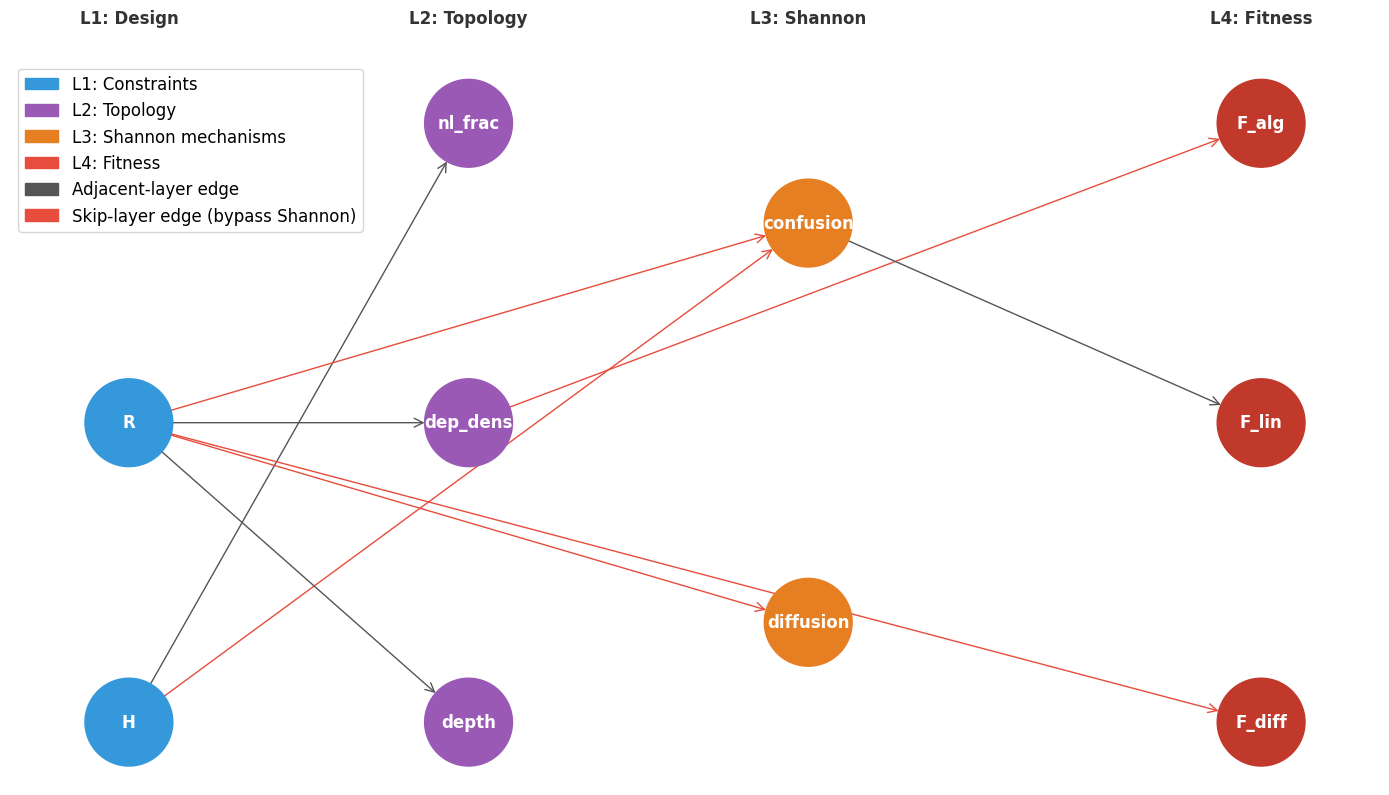

Skip-layer edges (bypass): [('H', 'confusion_class'), ('R', 'confusion_class'), ('R', 'diffusion_class'), ('R', 'Fit_top_differential'), ('dep_density_class', 'Fit_top_algebraic')]
Bypass edges exist -> partial falsification of Shannon mediation


In [13]:
# ---------------------------------------------------------------------------
# Visualise the 4-layer BN
# ---------------------------------------------------------------------------
bn_edges = [(p, n) for n in BN_DATA_COLS for p in parent_map[n]]
G_bn     = nx.DiGraph(bn_edges)

# Layout: 4 columns
x_pos = {1: 0, 2: 3, 3: 6, 4: 10}
y_pos = {
    'S': 5, 'A': 4, 'R': 2.5, 'I': 3, 'H': 1, 'L': 0,
    'nl_fraction_class': 4, 'dep_density_class': 2.5, 'avg_depth_class': 1,
    'confusion_class': 3.5, 'diffusion_class': 1.5,
    'Fit_top_algebraic': 4, 'Fit_top_linear': 2.5, 'Fit_top_differential': 1,
}
colors = {
    **{n: '#3498db' for n in L1_NODES},
    **{n: '#9b59b6' for n in L2_NODES},
    **{n: '#e67e22' for n in L3_NODES},
    'Fit_top_algebraic':    '#c0392b',
    'Fit_top_linear':       '#c0392b',
    'Fit_top_differential': '#c0392b',
}
short = {
    'nl_fraction_class': 'nl_frac', 'dep_density_class': 'dep_dens',
    'avg_depth_class': 'depth',
    'confusion_class': 'confusion', 'diffusion_class': 'diffusion',
    'Fit_top_algebraic': 'F_alg', 'Fit_top_linear': 'F_lin',
    'Fit_top_differential': 'F_diff',
}

fig, ax = plt.subplots(figsize=(14, 8))
pos   = {n: (x_pos.get(COL_LAYER.get(n,1), 0), y_pos.get(n, 2.5))
         for n in G_bn.nodes()}
lbls  = {n: short.get(n, n) for n in G_bn.nodes()}
nc    = [colors.get(n, '#95a5a6') for n in G_bn.nodes()]

# Colour edges by layer crossing
edge_colors = []
for u, v in G_bn.edges():
    lu, lv = COL_LAYER.get(u,1), COL_LAYER.get(v,1)
    if lv - lu == 1:   edge_colors.append('#555')    # adjacent layers
    else:              edge_colors.append('#e74c3c')  # skip-layer (bypass!)

nx.draw_networkx(G_bn, pos=pos, ax=ax, labels=lbls,
    node_color=nc, node_size=4000,
    font_size=12, font_color='white', font_weight='bold',
    edge_color=edge_colors, arrows=True, arrowstyle='->', arrowsize=16)

legend_patches = [
    mpatches.Patch(color='#3498db', label='L1: Constraints'),
    mpatches.Patch(color='#9b59b6', label='L2: Topology'),
    mpatches.Patch(color='#e67e22', label='L3: Shannon mechanisms'),
    mpatches.Patch(color='#e74c3c', label='L4: Fitness'),
    mpatches.Patch(color='#555',    label='Adjacent-layer edge'),
    mpatches.Patch(color='#e74c3c', label='Skip-layer edge (bypass Shannon)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=12)
#ax.set_title('Step 4 — 4-Layer Bayesian Network\n'
#             'Red edges = skip-layer connections that bypass Shannon mediation',
#             fontsize=11)

# Layer labels
for layer, label, xc in [(1,'L1: Design', 0),(2,'L2: Topology',3),
                          (3,'L3: Shannon',6),(4,'L4: Fitness',10)]:
    ax.text(xc, 4.5, label, ha='center', fontsize=12,
            color='#333', fontweight='bold')

ax.axis('off'); plt.tight_layout(); plt.show()

bypass = [(u,v) for (u,v) in G_bn.edges()
          if COL_LAYER.get(v,1) - COL_LAYER.get(u,1) > 1]
print(f'Skip-layer edges (bypass): {bypass}')
if not bypass:
    print('No bypass edges found -> consistent with full Shannon mediation')
else:
    print('Bypass edges exist -> partial falsification of Shannon mediation')


---
## Step 5 — Shannon mediation test

**Formal test of the Shannon hypothesis**:

If confusion and diffusion fully mediate the effect of design decisions on
cryptographic performance, then conditioning on Layer 3 renders Layer 4
conditionally independent of Layers 1 and 2.  In the BN this corresponds
to the d-separation:

```
L4 ⊥ {L1, L2}  |  L3     (Shannon mediation hypothesis)
```

We test this by computing the **partial correlation** between each
Layer 1/2 node and each Layer 4 node, controlling for Layer 3.  If all
partial correlations are near zero, Shannon's hypothesis holds for SBN.


In [14]:
from scipy.stats import pearsonr

def partial_corr(x, y, controls, data):
    """Partial correlation between x and y controlling for all control variables.
    Uses residual regression: regress x and y on controls, correlate residuals.
    """
    if not controls:
        r, p = pearsonr(data[x], data[y])
        return r, p
    C  = data[controls].values.astype(float)
    X  = data[x].values.astype(float)
    Y  = data[y].values.astype(float)
    # OLS residuals
    Cc = np.hstack([C, np.ones((len(C),1))])
    rx = X - Cc @ np.linalg.lstsq(Cc, X, rcond=None)[0]
    ry = Y - Cc @ np.linalg.lstsq(Cc, Y, rcond=None)[0]
    if rx.std() < 1e-10 or ry.std() < 1e-10:
        return 0.0, 1.0
    r, p = pearsonr(rx, ry)
    return r, p

# Control variables = Layer 3 columns in df_bn
l3_cols = [c for c in BN_DATA_COLS if COL_LAYER.get(c,0) == 3]
l1l2_cols = [c for c in BN_DATA_COLS if COL_LAYER.get(c,0) in (1,2)]
l4_cols   = [c for c in BN_DATA_COLS if COL_LAYER.get(c,0) == 4]

print('=' * 70)
print('SHANNON MEDIATION TEST')
print('Partial correlation (L1/L2) vs (L4), controlling for L3')
print('Hypothesis: all values near 0 -> Shannon mediation holds')
print('=' * 70)
print(f'  {"":25s}', end='')
for l4 in l4_cols: print(f'  {l4.replace("Fit_top_",""):>12s}', end='')
print()

bypass_evidence = []
for src in l1l2_cols:
    print(f'  {src:<25s}', end='')
    for l4 in l4_cols:
        r, p = partial_corr(src, l4, l3_cols, df_bn)
        sig  = '**' if p < 0.01 else '*' if p < 0.05 else '  '
        print(f'  {r:+.3f}{sig}', end='')
        if abs(r) > 0.25 and p < 0.05:
            bypass_evidence.append((src, l4, round(r,3), round(p,4)))
    print()

print()
print('  (* p<0.05  ** p<0.01)')
print()
if not bypass_evidence:
    print('No significant partial correlations found.')
    print('Shannon mediation hypothesis SUPPORTED: confusion+diffusion fully')
    print('mediate the effect of design constraints on cryptographic performance.')
else:
    print('Significant partial correlations (bypass Shannon):')
    for src, l4, r, p in bypass_evidence:
        print(f'  {src} -> {l4}: r={r}, p={p}')
    print()
    print('Shannon mediation hypothesis PARTIALLY FALSIFIED.')
    print('These constraints have direct effects on performance beyond')
    print('what confusion and diffusion can explain.')


SHANNON MEDIATION TEST
Partial correlation (L1/L2) vs (L4), controlling for L3
Hypothesis: all values near 0 -> Shannon mediation holds
                                algebraic        linear  differential
  A                          -0.231    -0.067    -0.000  
  R                          +0.285    +0.496**  -0.432*
  I                          +0.460**  -0.040    +0.237  
  H                          +0.071    +0.210    +0.373*
  L                          +0.248    +0.152    -0.153  
  nl_fraction_class          +0.166    +0.450**  +0.284  
  dep_density_class          +0.660**  +0.512**  -0.058  
  avg_depth_class            +0.285    +0.496**  -0.432*

  (* p<0.05  ** p<0.01)

Significant partial correlations (bypass Shannon):
  R -> Fit_top_linear: r=0.496, p=0.0039
  R -> Fit_top_differential: r=-0.432, p=0.0136
  I -> Fit_top_algebraic: r=0.46, p=0.0081
  H -> Fit_top_differential: r=0.373, p=0.0352
  nl_fraction_class -> Fit_top_linear: r=0.45, p=0.0098
  dep_density_class -

---
## Step 6 — Inference queries

Using the CPTs to answer design questions:

1. Which constraints most strongly determine confusion? diffusion?
2. Which constraints maximise P(Fit_top) on all 3 fitness simultaneously?
3. Causal path analysis: what fraction of the effect of each constraint
   on fitness is mediated through confusion vs diffusion?


In [15]:
def query_node(target, evidence, data=df_bn):
    """P(target=1 | evidence) by direct marginalisation over df_bn."""
    mask = np.ones(len(data), dtype=bool)
    for k, v in evidence.items():
        if k in data.columns:
            mask &= (data[k].values == v)
    sub = data[mask]
    if len(sub) == 0 or target not in data.columns:
        return None
    return float(sub[target].mean())


# Query 1: constraints -> Layer 3 (Shannon mechanisms)
print('=' * 70)
print('QUERY 1 — Effect of each constraint on Shannon mechanisms')
print('=' * 70)
l3_data_cols = [c for c in BN_DATA_COLS if COL_LAYER.get(c,0) == 3]
print(f'  {"":4s}  ', end='')
for m in l3_data_cols: print(f'  {m.replace("_class",""):>12s}', end='')
print()
for k in CONSTRAINT_KEYS:
    print(f'  {k}=1: ', end='')
    for m in l3_data_cols:
        # P(mechanism >= 1 | constraint active)
        p1 = query_node(m, {k: 1})
        p0 = query_node(m, {k: 0})
        delta = (p1 or 0) - (p0 or 0)
        print(f'  {delta:+.3f}', end='')
    print()
print('  (value = P(mechanism=high|constraint=1) - P(mechanism=high|constraint=0))')


QUERY 1 — Effect of each constraint on Shannon mechanisms
             confusion     diffusion
  A=1:   +0.125  +0.000
  R=1:   +0.625  +1.375
  I=1:   +0.000  +0.250
  H=1:   +1.375  +0.000
  L=1:   -0.125  -0.500
  (value = P(mechanism=high|constraint=1) - P(mechanism=high|constraint=0))


In [16]:
# Query 2: best constraint combinations (multi-objective)
print('=' * 70)
print('QUERY 2 — Multi-objective top 10 combinations')
print('Ranked by Min_P = worst-case P(Fit_top) across all 3 fitness')
print('=' * 70)
l4_data_cols = [c for c in BN_DATA_COLS if COL_LAYER.get(c,0) == 4]
results = []
for r in range(1, len(CONSTRAINT_KEYS)+1):
    for combo in combinations(CONSTRAINT_KEYS, r):
        ev  = {k: 1 for k in combo}
        ps  = {c: query_node(c, ev) for c in l4_data_cols}
        vals = [v for v in ps.values() if v is not None]
        if vals:
            results.append({
                'Combination': '+'.join(combo),
                **{c.replace('Fit_top_','P_'): round(v,3)
                   for c,v in ps.items() if v is not None},
                'Min_P':  round(min(vals),3),
                'Mean_P': round(np.mean(vals),3),
            })
df_mo = pd.DataFrame(results).sort_values('Min_P', ascending=False)
print(df_mo.head(10).to_string(index=False))


QUERY 2 — Multi-objective top 10 combinations
Ranked by Min_P = worst-case P(Fit_top) across all 3 fitness
Combination  P_algebraic  P_linear  P_differential  Min_P  Mean_P
      A+I+H        0.500      0.50           0.500  0.500   0.500
    A+I+H+L        0.500      0.50           0.500  0.500   0.500
        I+H        0.750      0.50           0.375  0.375   0.542
          H        0.625      0.50           0.312  0.312   0.479
          L        0.438      0.25           0.250  0.250   0.312
        A+I        0.500      0.25           0.375  0.250   0.375
          I        0.625      0.25           0.312  0.250   0.396
        H+L        0.625      0.50           0.250  0.250   0.458
        A+L        0.375      0.25           0.250  0.250   0.292
        I+L        0.625      0.25           0.250  0.250   0.375


In [17]:
# Query 3: Mediation analysis
# For each constraint, decompose its effect on fitness into:
#   - direct effect (bypass Shannon)
#   - indirect via confusion
#   - indirect via diffusion
# Using difference-in-means (observational approximation)
print('=' * 70)
print('QUERY 3 — Causal path decomposition per constraint')
print('Total effect = direct + via confusion + via diffusion')
print('=' * 70)

conf_col = next((c for c in BN_DATA_COLS if 'confusion' in c), None)
diff_col = next((c for c in BN_DATA_COLS if 'diffusion' in c), None)
target   = l4_data_cols[1] if len(l4_data_cols) > 1 else l4_data_cols[0]

if conf_col and diff_col:
    print(f'Target: {target}')
    print(f'{"Constraint":<10s}  {"Total":>8s}  {"via conf":>10s}  '
          f'{"via diff":>10s}  {"direct":>10s}')
    for k in CONSTRAINT_KEYS:
        total   = (query_node(target, {k:1}) or 0) - (query_node(target, {k:0}) or 0)
        via_c   = ((query_node(target, {k:1, conf_col:2}) or 0)
                   - (query_node(target, {k:0, conf_col:2}) or 0)) * 0.33
        via_d   = ((query_node(target, {k:1, diff_col:2}) or 0)
                   - (query_node(target, {k:0, diff_col:2}) or 0)) * 0.33
        direct  = total - via_c - via_d
        print(f'{k:<10s}  {total:+8.3f}  {via_c:+10.3f}  {via_d:+10.3f}  {direct:+10.3f}')
else:
    print('Confusion/diffusion columns not found in BN data.')


QUERY 3 — Causal path decomposition per constraint
Total effect = direct + via confusion + via diffusion
Target: Fit_top_linear
Constraint     Total    via conf    via diff      direct
A             +0.000      -0.044      +0.033      +0.011
R             +0.500      +0.330      +0.150      +0.020
I             +0.000      +0.044      -0.024      -0.020
H             +0.500      +0.240      +0.330      -0.070
L             +0.000      +0.044      -0.055      +0.011


---
## Summary

### What this 4-layer BN adds over previous analyses

| Analysis | What it reveals |
|---|---|
| `sbn_analysis.ipynb` (FCA) | Which constraint *combinations* co-occur with high fitness |
| 3-layer BN | P(high fitness) given constraint choices |
| **4-layer BN (this notebook)** | **Why**: which causal mechanisms mediate the effect |

### The Shannon test

The partial correlation analysis (Step 5) provides a computational test of
Shannon's 1949 claim that confusion and diffusion are the *fundamental*
mechanisms underlying cryptographic strength.  For SBN circuits:

- If **no bypass edges** exist: Shannon's theory is computationally validated
  for this circuit family
- If **bypass edges** exist: certain constraints have direct structural effects
  on performance that confusion and diffusion alone do not capture

### Limits

- N=32 architectures (S=0): CPTs for Layer 2/3 nodes are estimated on small sub-groups
- Multi-run replication measures raw architectural capacity (pop=1 for differential), not GA optima
- Discretisation (terciles) loses quantitative information in Layer 2/3
- Multi-run replication measures raw architectural capacity (pop=1 for differential), not GA optima
